In [1]:
import sys
sys.path.append("../")

import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
n = len(data)
q1, q2 = n // 4, n // 2

print(f"Total: {n}  |  Q1 (beta): 0–{q1}  |  Q2 (train): {q1}–{q2}  |  test: {q2}–{n}")

jres = coint_johansen(np.log(data.s[:, :q1]).T, det_order=0, k_ar_diff=1)
cv   = jres.evec[:, 0]
beta = -cv[1] / cv[0]
intercept = float((np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1])).mean())
print(f"β = {beta:.4f}  |  intercept = {intercept:.4f}")

Total: 5032  |  Q1 (beta): 0–1258  |  Q2 (train): 1258–2516  |  test: 2516–5032
β = 1.0437  |  intercept = 0.5396


In [2]:
%matplotlib widget

In [3]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C
from env import Market

class FlatMarket(gym.Wrapper):
    """Flattens dict obs to [z_score, entry_z, spread, entry_spread, position] for SB3."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(
            low= np.array([-np.inf, -np.inf, -np.inf, -np.inf, 0.0], dtype=np.float32),
            high=np.array([ np.inf,  np.inf,  np.inf,  np.inf, 1.0], dtype=np.float32),
        )

    def _flatten(self, obs):
        return np.array([
            obs["spread_z_score"][0],
            obs["entry_z_score"][0],
            obs["spread"][0],
            obs["entry_spread"][0],
            float(obs["position"]),
        ], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._flatten(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        return self._flatten(obs), reward, term, trunc, info

train_data = data.slice(q1, q2)
train_env  = FlatMarket(Market(train_data, fixed_beta=beta, spread_intercept=intercept, sparse_reward=True))

TOTAL_STEPS = len(train_data) * 100
print(f"Training for {TOTAL_STEPS:,} steps  |  n_steps=50  |  sparse_reward=True")

model = A2C("MlpPolicy", train_env, verbose=1, ent_coef=0.01, n_steps=50)
model.learn(total_timesteps=TOTAL_STEPS)
print("Done.")

Training for 125,800 steps  |  n_steps=50  |  sparse_reward=True
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 1.2e+03  |
|    ep_rew_mean        | 1.47e+04 |
| time/                 |          |
|    fps                | 2375     |
|    iterations         | 100      |
|    time_elapsed       | 2        |
|    total_timesteps    | 5000     |
| train/                |          |
|    entropy_loss       | -0.207   |
|    explained_variance | 0.0156   |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 67.5     |
|    value_loss         | 1.2e+05  |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 1.2e+03  |
|    ep_rew_mean        | 1.79e+04 |
| time/                 |          |
|    fps                | 2

--- A2C (train) ---


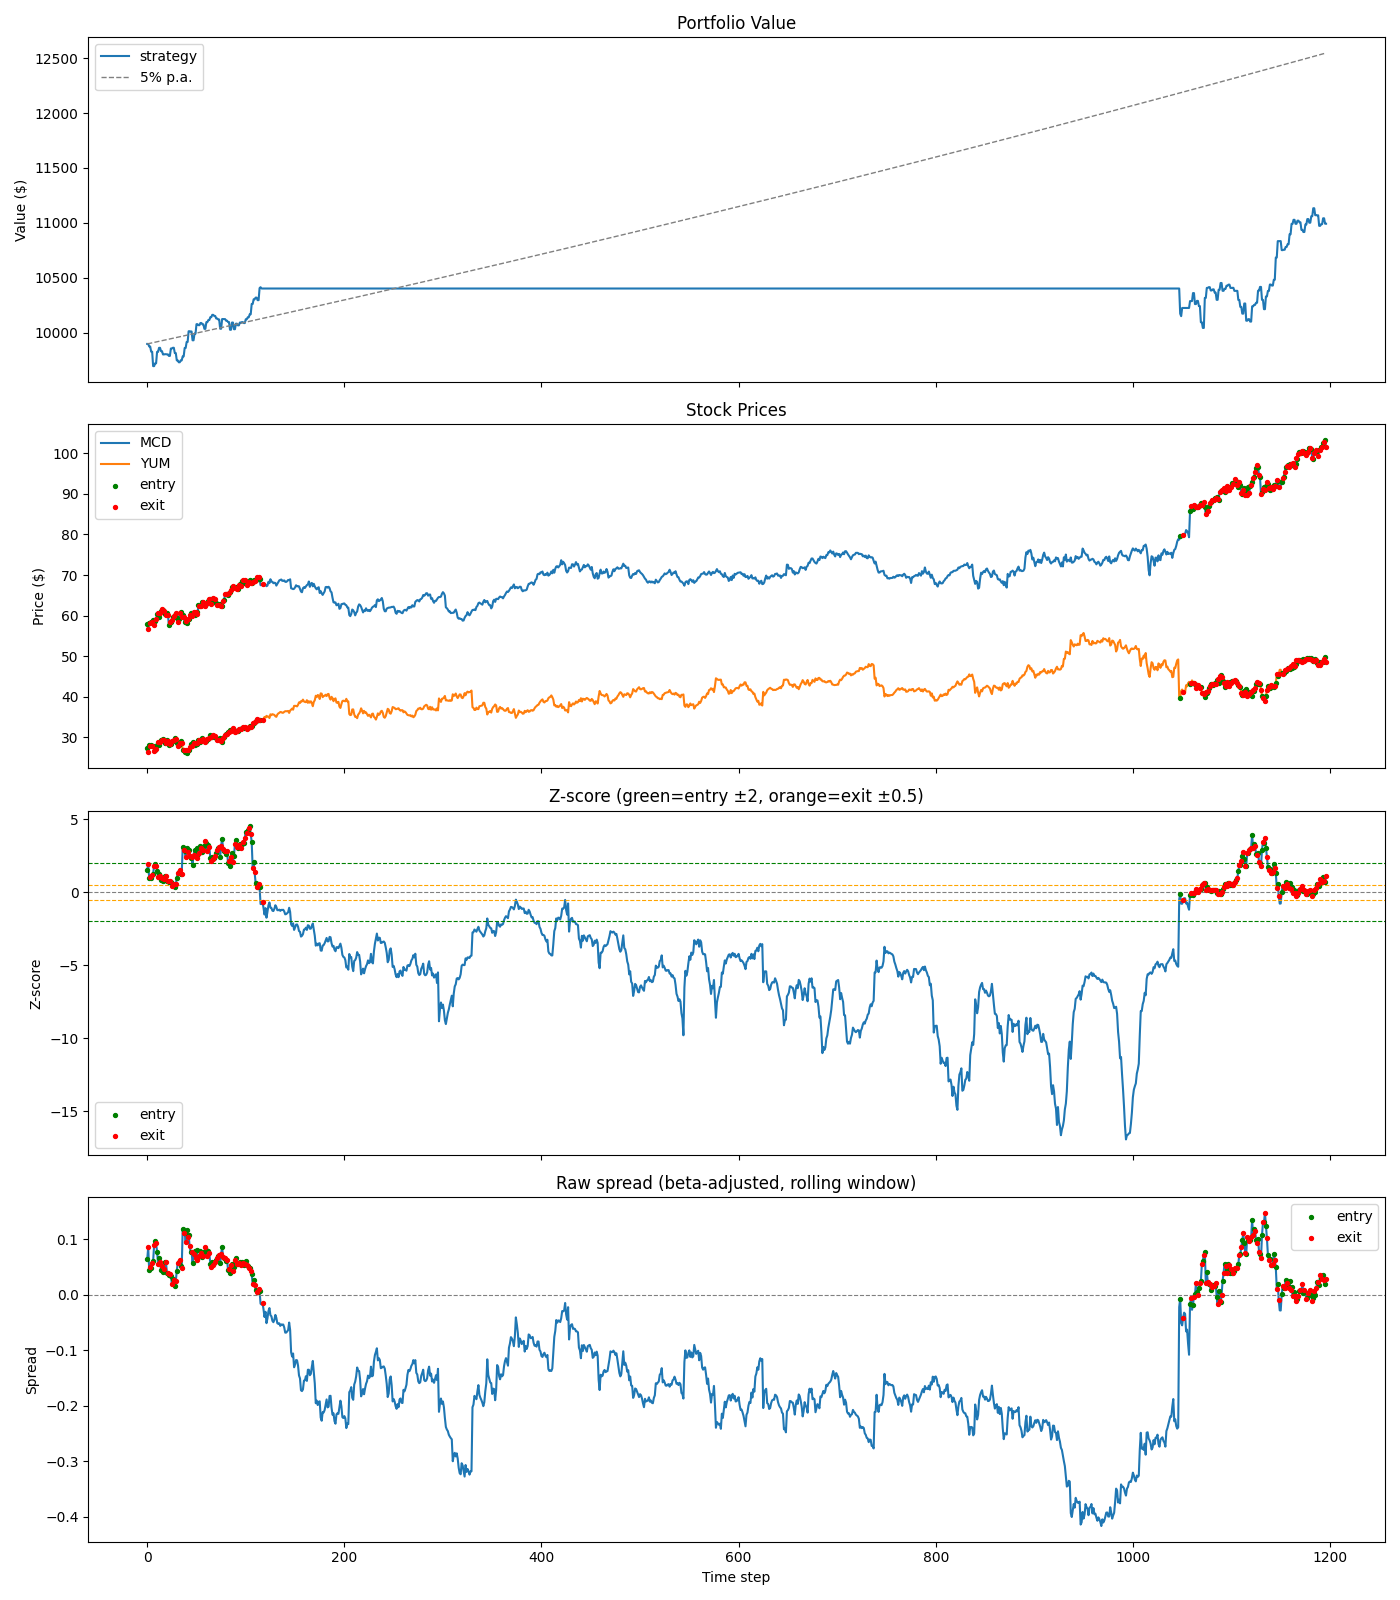

--- A2C (test) ---


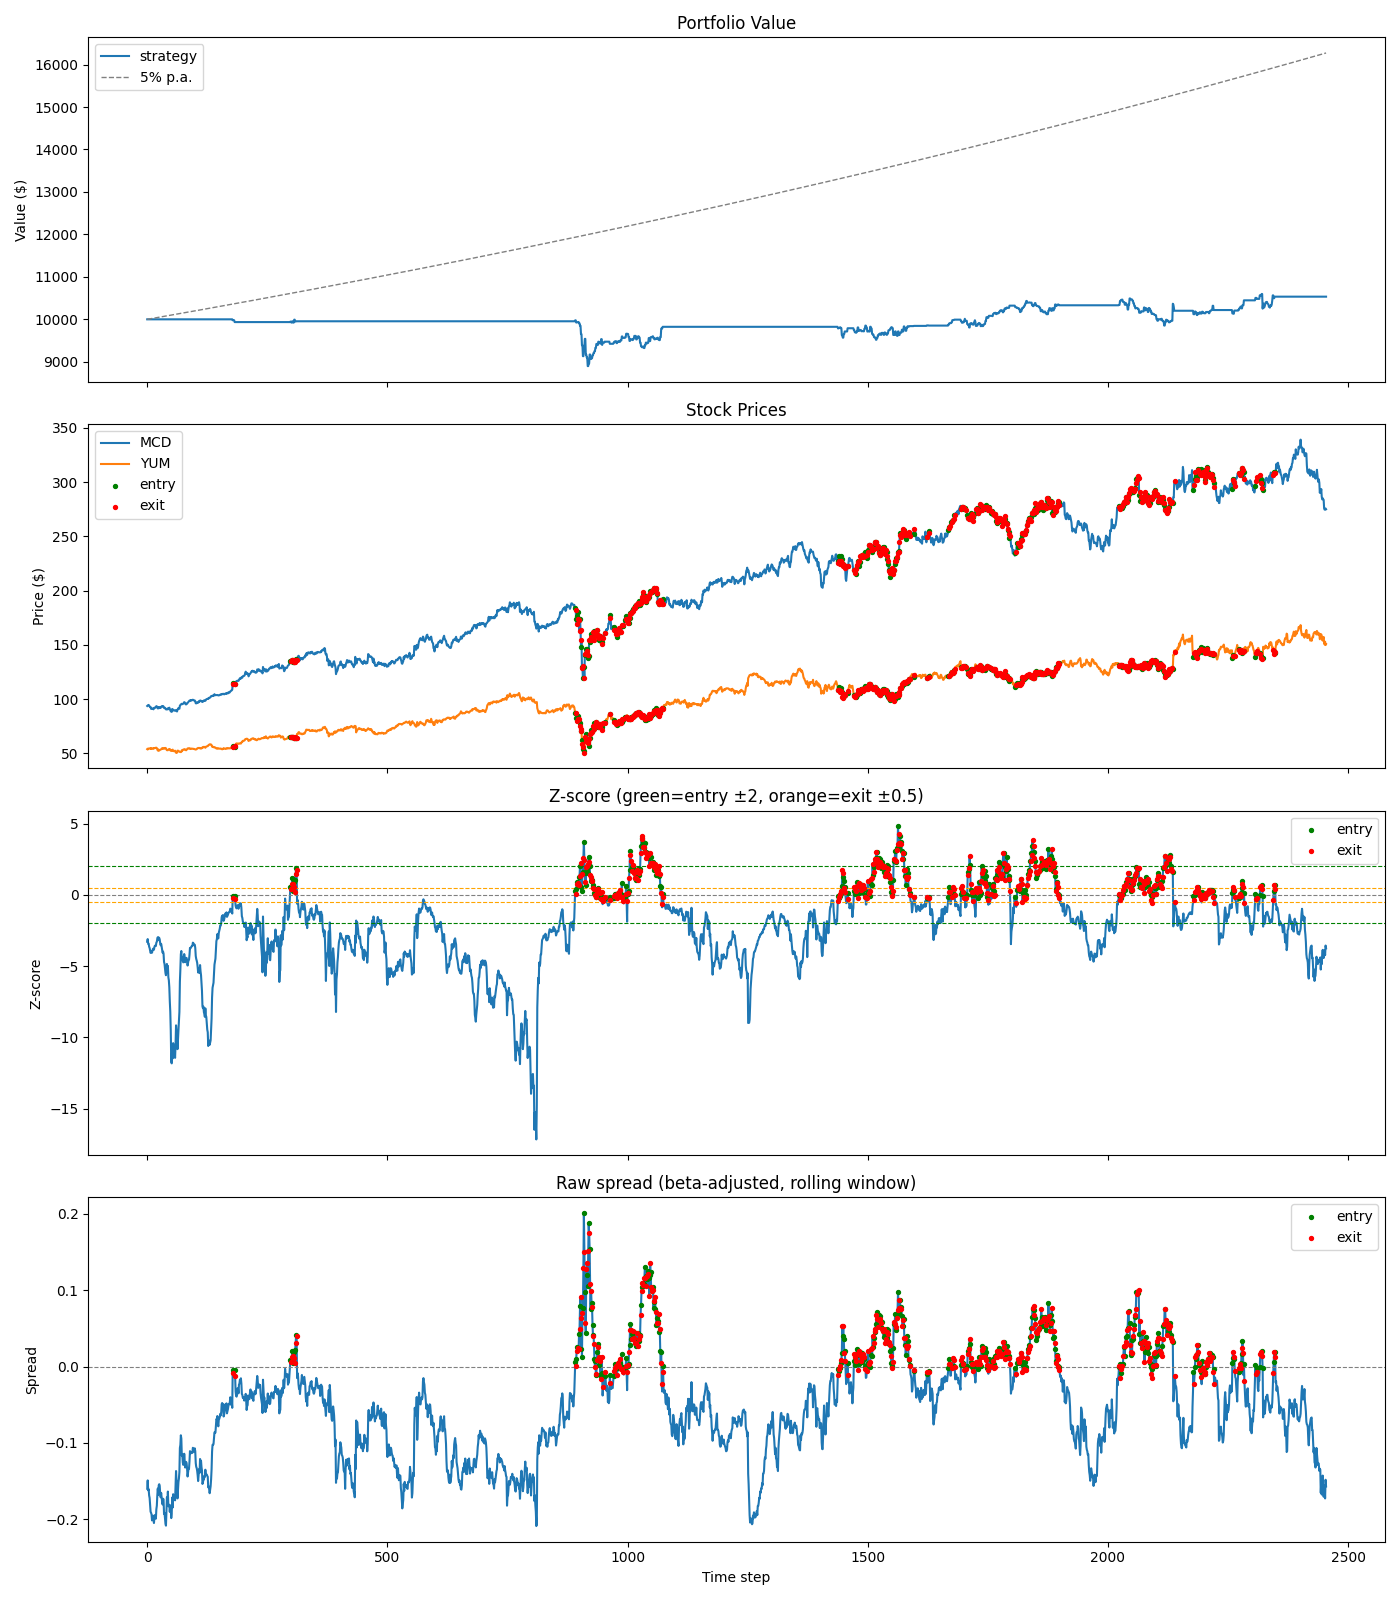

--- Z-score baseline (test) ---


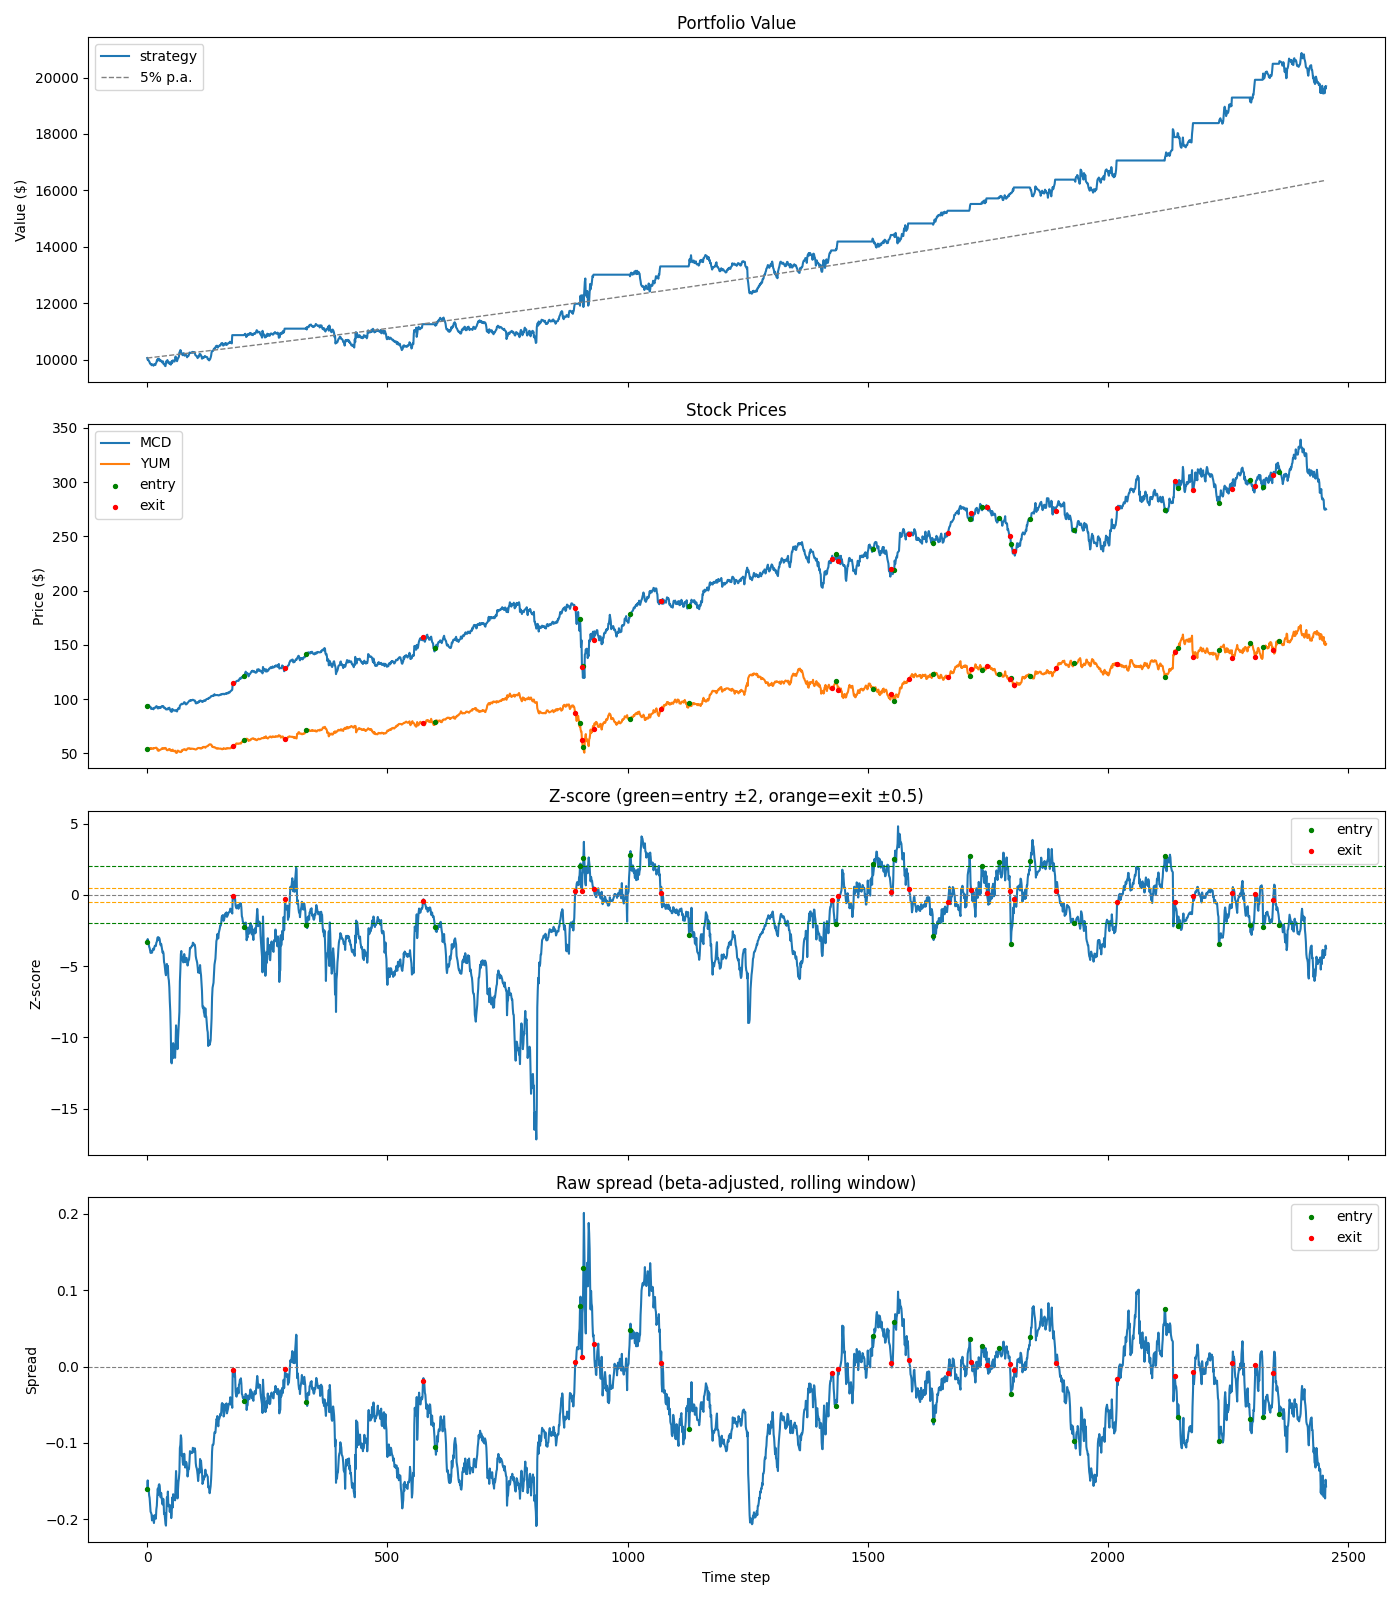

In [4]:
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

class SB3Agent:
    def __init__(self, model):
        self.model = model

    def predict(self, obs):
        flat = np.array([
            obs["spread_z_score"][0],
            obs["entry_z_score"][0],
            obs["spread"][0],
            obs["entry_spread"][0],
            float(obs["position"]),
        ], dtype=np.float32)
        action, _ = self.model.predict(flat, deterministic=True)
        return int(action)

test_data  = data.slice(q2)
train_data = data.slice(q1, q2)

# A2C on training data
results_a2c_train = run_strategy(Market(train_data, fixed_beta=beta, spread_intercept=intercept), SB3Agent(model))
print("--- A2C (train) ---")
plot_strategy(results_a2c_train)

# A2C on test data
results_a2c_test = run_strategy(Market(test_data, fixed_beta=beta, spread_intercept=intercept), SB3Agent(model))
print("--- A2C (test) ---")
plot_strategy(results_a2c_test)

# Z-score baseline on test data
results_base = run_strategy(Market(test_data, fixed_beta=beta, spread_intercept=intercept), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline (test) ---")
plot_strategy(results_base)